In [24]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score
)
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\anubh\OneDrive\Desktop\AI-medical-assistant\data\liver\Liver_dataset.csv",
    encoding='latin1'
)

In [5]:
df.head()

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [6]:
df.columns = (
    df.columns
    .str.replace('\xa0', '', regex=False)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [7]:
df.head()

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [8]:
df.rename(columns={
    "Age of the patient"                      : "age",
    "Gender of the patient"                   : "gender",
    "Total Bilirubin"                         : "total_bilirubin",
    "Direct Bilirubin"                        : "direct_bilirubin",
    "Alkphos Alkaline Phosphotase"            : "alkaline_phosphotase",
    "Sgpt Alamine Aminotransferase"           : "alamine_aminotransferase",
    "Sgot Aspartate Aminotransferase"         : "aspartate_aminotransferase",
    "Total Protiens"                          : "total_proteins",
    "ALB Albumin"                             : "albumin",
    "A/G Ratio Albumin and Globulin Ratio"    : "ag_ratio",
    "Result"                                  : "target"
}, inplace=True)

In [9]:
df["target"] = df["target"].map({1: 1, 2: 0})
 
print("Shape          :", df.shape)
print("Columns        :", df.columns.tolist())
print("Missing values :\n", df.isnull().sum())
print("\nClass distribution (1 = Liver Disease, 0 = No Disease):")
print(df["target"].value_counts())
ratio = df["target"].value_counts()[1] / df["target"].value_counts()[0]
print(f"Imbalance ratio: {ratio:.2f}:1  (disease:no-disease)")

Shape          : (30691, 11)
Columns        : ['age', 'gender', 'total_bilirubin', 'direct_bilirubin', 'alkaline_phosphotase', 'alamine_aminotransferase', 'aspartate_aminotransferase', 'total_proteins', 'albumin', 'ag_ratio', 'target']
Missing values :
 age                             2
gender                        902
total_bilirubin               648
direct_bilirubin              561
alkaline_phosphotase          796
alamine_aminotransferase      538
aspartate_aminotransferase    462
total_proteins                463
albumin                       494
ag_ratio                      559
target                          0
dtype: int64

Class distribution (1 = Liver Disease, 0 = No Disease):
target
1    21917
0     8774
Name: count, dtype: int64
Imbalance ratio: 2.50:1  (disease:no-disease)


In [10]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)

C:\Windows\Temp\ipykernel_10412\4193680292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna(df["gender"].mode()[0], inplace=True)


In [11]:
num_cols = df.select_dtypes(include=np.number).columns.drop("target")
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
 
print(f"\nMissing after imputation: {df.isnull().sum().sum()}")


Missing after imputation: 0


C:\Windows\Temp\ipykernel_10412\3403864672.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [12]:
bounds = {
    "age"                        : (4,   90),
    "total_bilirubin"            : (0.1, 75),
    "direct_bilirubin"           : (0.1, 20),
    "alkaline_phosphotase"       : (20,  2500),
    "alamine_aminotransferase"   : (5,   2000),
    "aspartate_aminotransferase" : (5,   5000),
    "total_proteins"             : (2,   12),
    "albumin"                    : (0.5, 6),
    "ag_ratio"                   : (0.1, 3.5),
}
for col, (lo, hi) in bounds.items():
    df[col] = df[col].clip(lo, hi)
 
print(f"Shape after clipping: {df.shape}")

Shape after clipping: (30691, 11)


In [13]:
# Bilirubin ratio — direct/total indicates hepatic vs haemolytic jaundice
df["bilirubin_ratio"]    = (df["direct_bilirubin"] / (df["total_bilirubin"] + 1e-6)).round(4)
 
# Enzyme ratio — AST/ALT ratio > 2 is a classical marker of alcoholic liver disease
df["de_ritis_ratio"]     = (df["aspartate_aminotransferase"] /
                             (df["alamine_aminotransferase"] + 1e-6)).round(4)
 
# Log transforms — liver enzyme distributions are highly right-skewed
for col in ["total_bilirubin", "direct_bilirubin", "alkaline_phosphotase",
            "alamine_aminotransferase", "aspartate_aminotransferase"]:
    df[f"log_{col}"] = np.log1p(df[col])
 
# Protein-albumin gap = globulin proxy (elevated in chronic liver disease)
df["globulin"]           = (df["total_proteins"] - df["albumin"]).round(4)
 
# Albumin flag — hypoalbuminemia (< 3.5 g/dL) indicates impaired liver synthesis
df["hypoalbuminemia"]    = (df["albumin"] < 3.5).astype(int)
 
# Elevated enzyme flag — ALT or AST > 40 (upper normal limit)
df["elevated_enzymes"]   = (
    (df["alamine_aminotransferase"] > 40) |
    (df["aspartate_aminotransferase"] > 40)
).astype(int)
 
# Jaundice flag — total bilirubin > 2.0 mg/dL
df["jaundice"]           = (df["total_bilirubin"] > 2.0).astype(int)
 
# Age group (0=young <30, 1=middle 30-60, 2=senior >60)
df["age_group"]          = pd.cut(df["age"], bins=[0, 30, 60, 100],
                                   labels=[0, 1, 2]).astype(int)
 
# Encode gender
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])   # Male=1, Female=0 (typically)
 
print(f"Shape after feature engineering: {df.shape}")
print(f"Total features: {df.drop('target', axis=1).shape[1]}")

Shape after feature engineering: (30691, 23)
Total features: 22



── Feature Statistics ──────────────────────────────────────
            age    gender  total_bilirubin  direct_bilirubin  alkaline_phosphotase  alamine_aminotransferase  aspartate_aminotransferase  total_proteins   albumin  ag_ratio    target  bilirubin_ratio  de_ritis_ratio  log_total_bilirubin  log_direct_bilirubin  log_alkaline_phosphotase  log_alamine_aminotransferase  log_aspartate_aminotransferase  globulin  hypoalbuminemia  elevated_enzymes  jaundice  age_group
count  30691.00  30691.00         30691.00          30691.00              30691.00                  30691.00                    30691.00        30691.00  30691.00  30691.00  30691.00         30691.00        30691.00             30691.00              30691.00                  30691.00                      30691.00                        30691.00  30691.00         30691.00          30691.00  30691.00   30691.00
mean      44.11      0.75             3.32              1.51                287.00                     80.67    

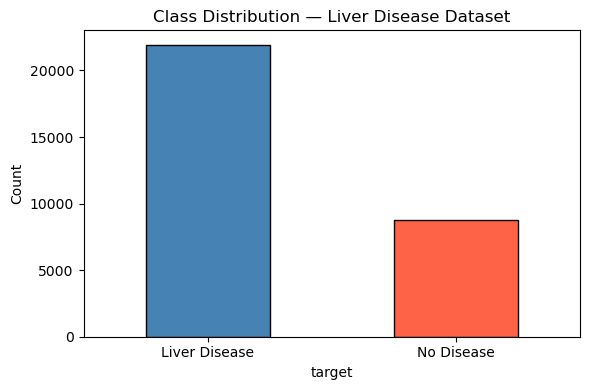

In [14]:
print("\n── Feature Statistics ──────────────────────────────────────")
print(df.describe().round(2).to_string())
 
# Class distribution
plt.figure(figsize=(6, 4))
df["target"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.xticks([0, 1], ["Liver Disease", "No Disease"], rotation=0)
plt.title("Class Distribution — Liver Disease Dataset")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

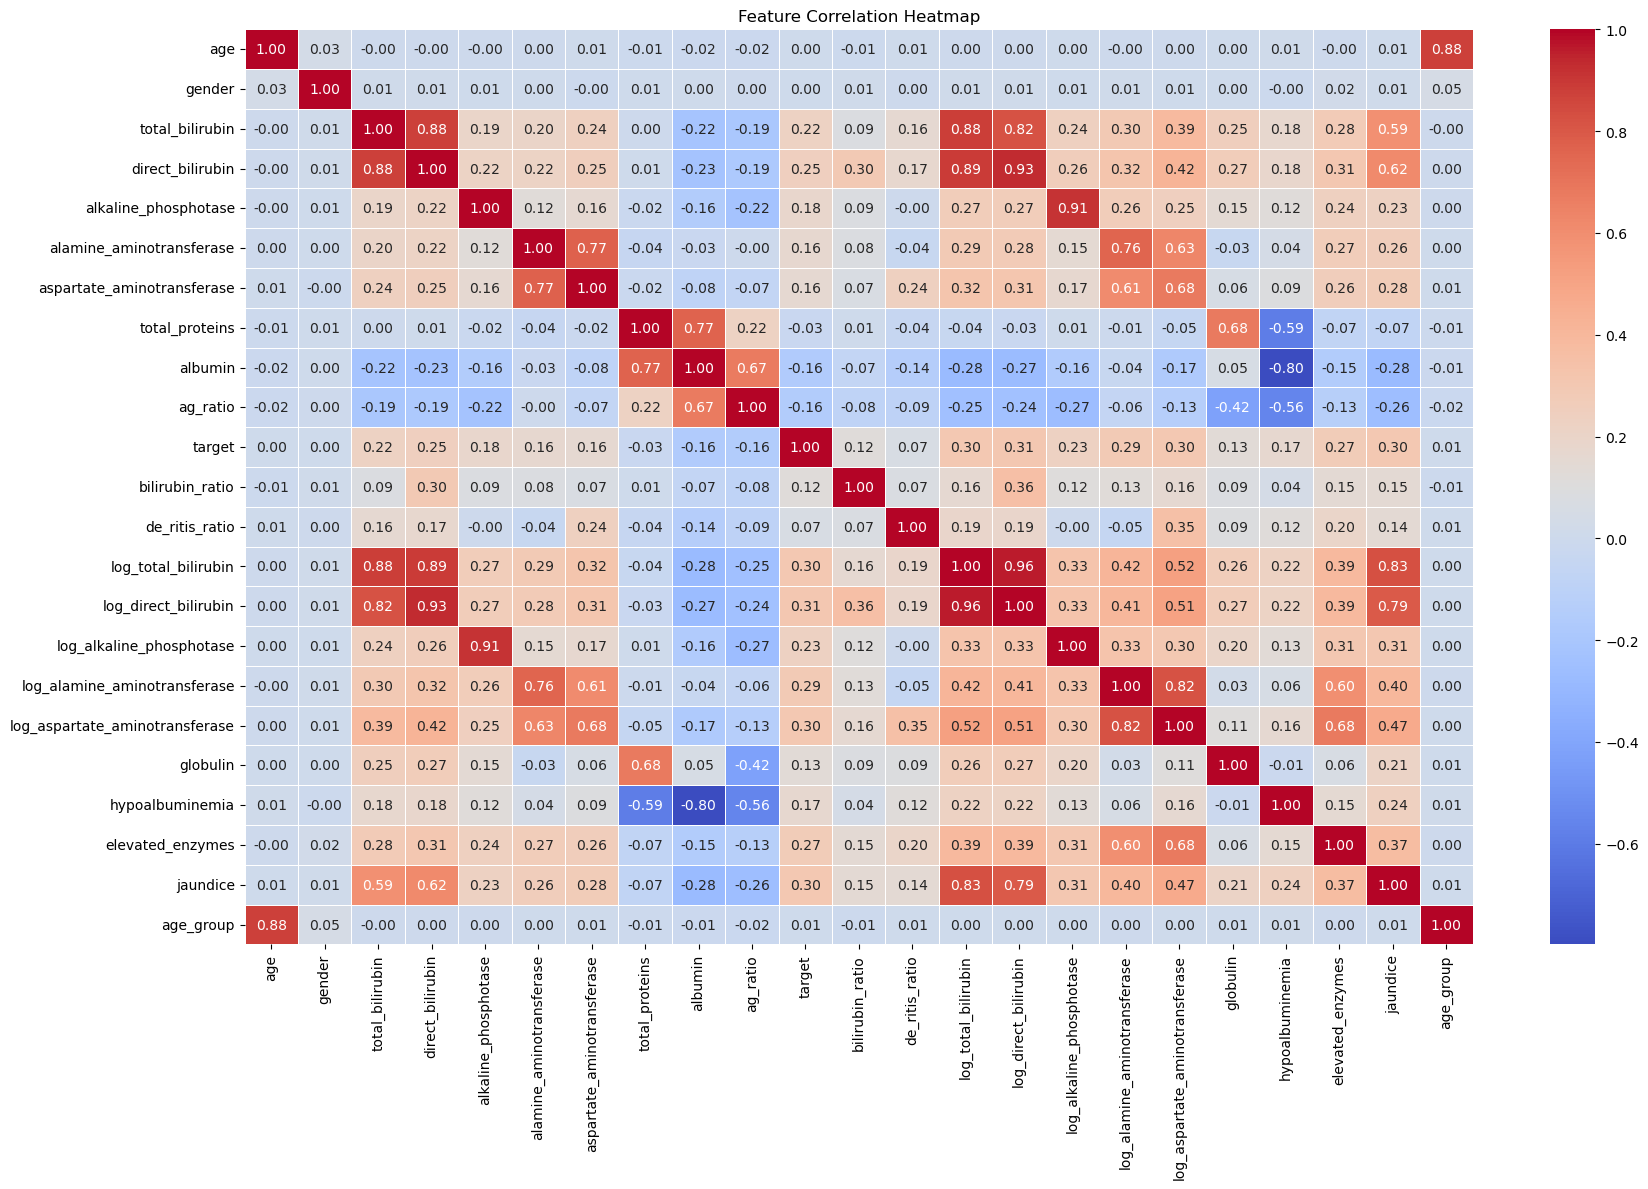

In [15]:
# Correlation heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

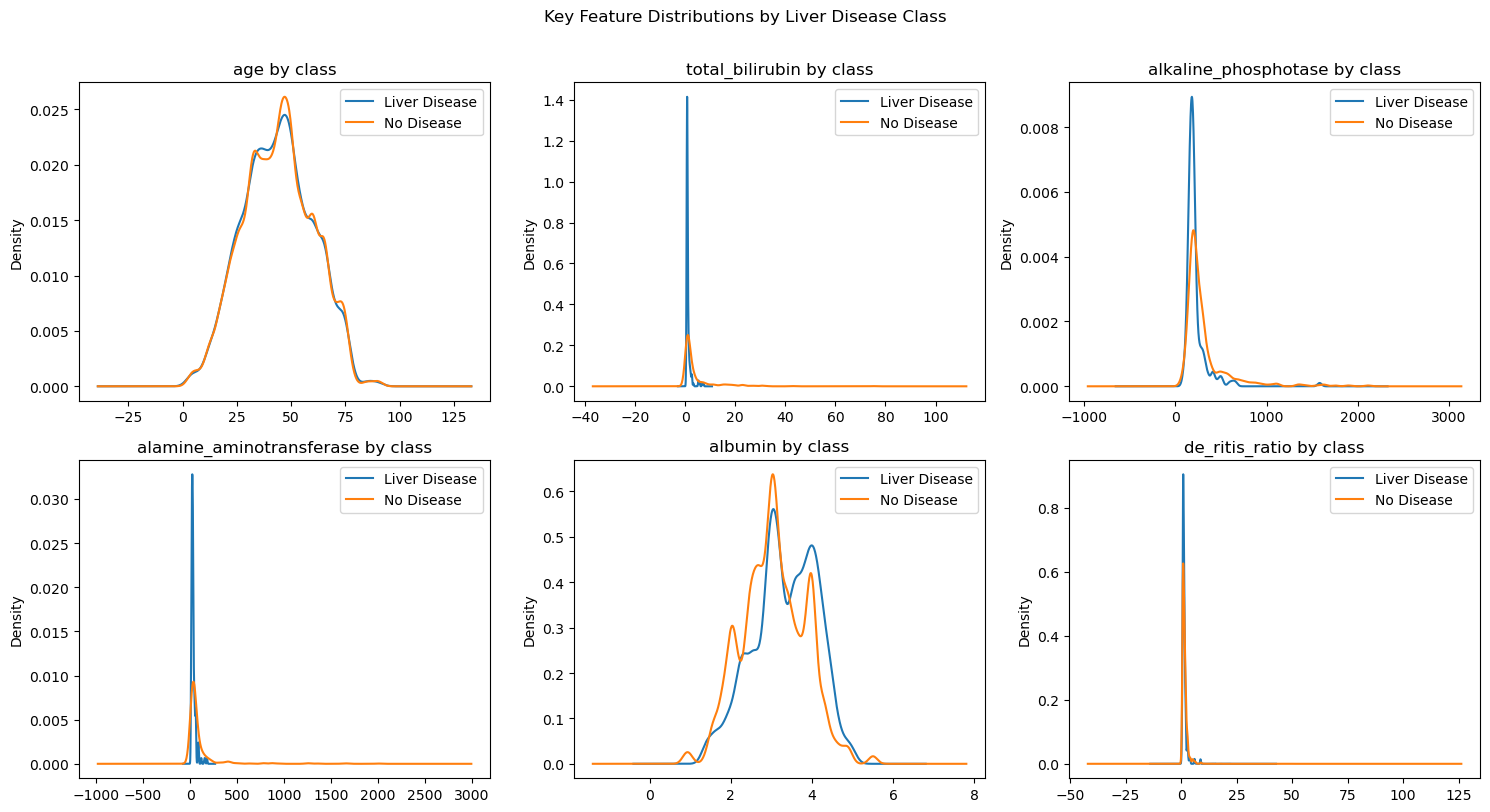

In [16]:
# Distribution of key features by class
key_feats = ["age", "total_bilirubin", "alkaline_phosphotase",
             "alamine_aminotransferase", "albumin", "de_ritis_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    df.groupby("target")[feat].plot(kind="kde", ax=ax, legend=True)
    ax.set_title(f"{feat} by class")
    ax.legend(["Liver Disease", "No Disease"])
plt.suptitle("Key Feature Distributions by Liver Disease Class", y=1.01)
plt.tight_layout()
plt.show()

In [17]:
X = df.drop("target", axis=1)
y = df["target"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)
 
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print("Train distribution (before resampling):", Counter(y_train))


Train: 24552  |  Test: 6139
Train distribution (before resampling): Counter({1: 17533, 0: 7019})


In [18]:
# ── Scale (LightGBM doesn't strictly need it, but helps calibration) ─────────
scaler   = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)
 
# ── Handle class imbalance with SMOTETomek ────────────────────────────────────
# Ratio ~2.5:1 (disease:no-disease) — apply only on train set
ratio_val = Counter(y_train)[1] / Counter(y_train)[0]
print(f"Class ratio (disease:no-disease): {ratio_val:.2f}")
 
if ratio_val > 1.5:
    smt = SMOTETomek(
        smote=SMOTE(sampling_strategy="auto", random_state=42, k_neighbors=5),
        random_state=42
    )
    X_train_res, y_train_res = smt.fit_resample(X_train_sc, y_train)
    print("SMOTETomek applied.")
else:
    X_train_res, y_train_res = X_train_sc, y_train
    print("Balanced — no SMOTE needed.")
 
print("Train distribution (after):", Counter(y_train_res))

Class ratio (disease:no-disease): 2.50
SMOTETomek applied.
Train distribution (after): Counter({1: 17515, 0: 17515})


In [19]:
neg = Counter(y_train_res)[0]
pos = Counter(y_train_res)[1]
spw = round(neg / pos, 3)
print(f"scale_pos_weight: {spw}")

scale_pos_weight: 1.0


In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
def objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 300, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves"        : trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples" : trial.suggest_int("min_child_samples", 10, 80),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 0.0, 2.0),
        "min_split_gain"    : trial.suggest_float("min_split_gain", 0.0, 0.5),
        "scale_pos_weight"  : spw,
        "random_state"      : 42,
        "n_jobs"            : -1,
        "verbose"           : -1,
    }
    clf = lgb.LGBMClassifier(**params)
    scores = cross_val_score(
        clf, X_train_res, y_train_res,
        cv=cv_inner, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()

In [25]:
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)
 
print(f"\nBest CV ROC-AUC : {study.best_value:.4f}")
print("Best params     :", study.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]


Best CV ROC-AUC : 0.9999
Best params     : {'n_estimators': 919, 'max_depth': 8, 'learning_rate': 0.04225579242184959, 'num_leaves': 209, 'min_child_samples': 79, 'subsample': 0.8773260535831456, 'colsample_bytree': 0.5353969913527721, 'reg_alpha': 0.01919683433573303, 'reg_lambda': 1.5423798077921038, 'min_split_gain': 0.00735983257222824}


In [26]:
best_params = study.best_params
best_params.update({
    "scale_pos_weight" : spw,
    "random_state"     : 42,
    "n_jobs"           : -1,
    "verbose"          : -1,
})
 
model = lgb.LGBMClassifier(**best_params)
model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_sc, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40, verbose=True),
        lgb.log_evaluation(period=100),
    ]
)

Training until validation scores don't improve for 40 rounds
[100]	valid_0's binary_logloss: 0.175424
[200]	valid_0's binary_logloss: 0.059219
[300]	valid_0's binary_logloss: 0.024727
[400]	valid_0's binary_logloss: 0.0147914
[500]	valid_0's binary_logloss: 0.0110444
[600]	valid_0's binary_logloss: 0.00902995
[700]	valid_0's binary_logloss: 0.00817641
[800]	valid_0's binary_logloss: 0.00745097
[900]	valid_0's binary_logloss: 0.00705032
Did not meet early stopping. Best iteration is:
[918]	valid_0's binary_logloss: 0.00700221


LGBMClassifier(colsample_bytree=0.5353969913527721,
               learning_rate=0.04225579242184959, max_depth=8,
               min_child_samples=79, min_split_gain=0.00735983257222824,
               n_estimators=919, n_jobs=-1, num_leaves=209, random_state=42,
               reg_alpha=0.01919683433573303, reg_lambda=1.5423798077921038,
               scale_pos_weight=1.0, subsample=0.8773260535831456, verbose=-1)

In [27]:
calibrated = CalibratedClassifierCV(model, method="isotonic", cv="prefit")
calibrated.fit(X_test_sc, y_test)

CalibratedClassifierCV(cv='prefit',
                       estimator=LGBMClassifier(colsample_bytree=0.5353969913527721,
                                                learning_rate=0.04225579242184959,
                                                max_depth=8,
                                                min_child_samples=79,
                                                min_split_gain=0.00735983257222824,
                                                n_estimators=919, n_jobs=-1,
                                                num_leaves=209, random_state=42,
                                                reg_alpha=0.01919683433573303,
                                                reg_lambda=1.5423798077921038,
                                                scale_pos_weight=1.0,
                                                subsample=0.8773260535831456,
                                                verbose=-1),
                       method='isotonic')

In [28]:
y_pred_prob = calibrated.predict_proba(X_test_sc)[:, 1]
 
thresholds = np.arange(0.20, 0.75, 0.01)
f1_macro   = [
    f1_score(y_test, (y_pred_prob >= t).astype(int), average="macro")
    for t in thresholds
]
best_thresh = thresholds[np.argmax(f1_macro)]
 
print(f"\nBest threshold (macro-F1) : {best_thresh:.2f}")
print(f"Best macro-F1             : {max(f1_macro):.4f}")
 
y_pred_best = (y_pred_prob >= best_thresh).astype(int)


Best threshold (macro-F1) : 0.34
Best macro-F1             : 0.9974


In [29]:
print("\n── Classification Report (tuned threshold) ─────────────────")
print(classification_report(
    y_test, y_pred_best,
    target_names=["No Disease", "Liver Disease"], digits=4
))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}")


── Classification Report (tuned threshold) ─────────────────
               precision    recall  f1-score   support

   No Disease     0.9977    0.9949    0.9963      1755
Liver Disease     0.9979    0.9991    0.9985      4384

     accuracy                         0.9979      6139
    macro avg     0.9978    0.9970    0.9974      6139
 weighted avg     0.9979    0.9979    0.9979      6139

ROC-AUC Score : 1.0000


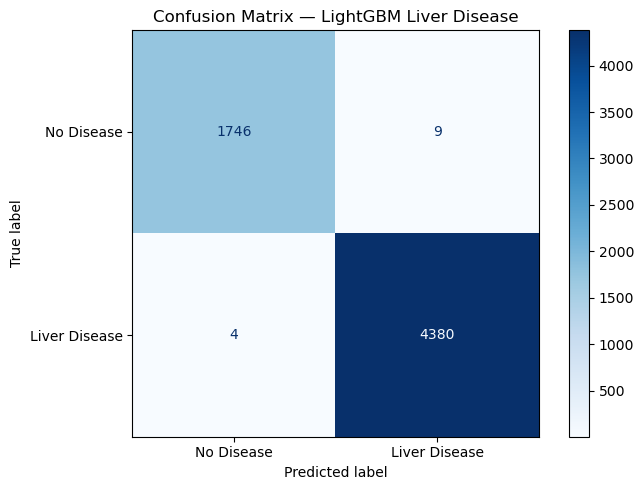

In [30]:
# -- Confusion Matrix ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Liver Disease"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
plt.title("Confusion Matrix — LightGBM Liver Disease")
plt.tight_layout()
plt.show()


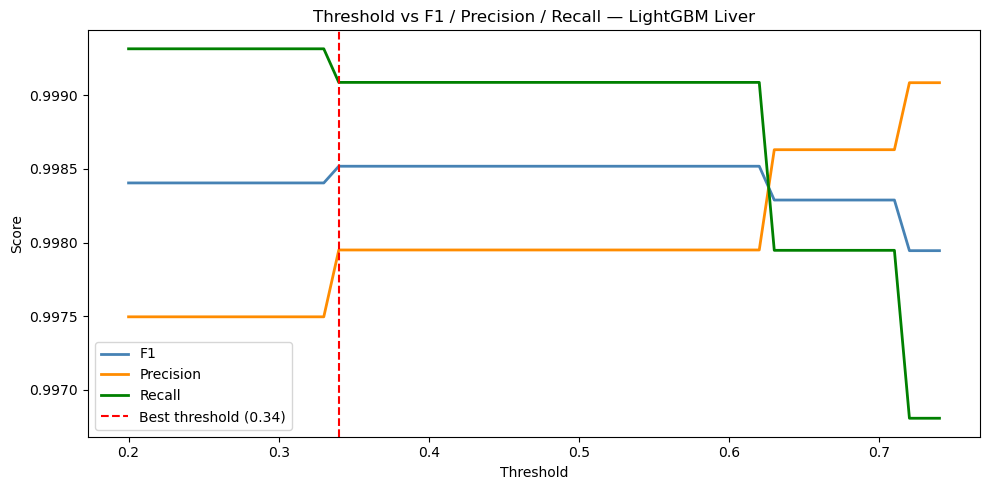

In [31]:
# -- Threshold vs Metrics curve -----------------------------------------------
precisions = [precision_score(y_test, (y_pred_prob >= t).astype(int), zero_division=0)
              for t in thresholds]
recalls    = [recall_score(y_test, (y_pred_prob >= t).astype(int))
              for t in thresholds]
f1_binary  = [f1_score(y_test, (y_pred_prob >= t).astype(int))
              for t in thresholds]
 
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_binary,  label="F1",        color="steelblue",  lw=2)
plt.plot(thresholds, precisions, label="Precision",  color="darkorange", lw=2)
plt.plot(thresholds, recalls,    label="Recall",     color="green",      lw=2)
plt.axvline(best_thresh, color="red", ls="--",
            label=f"Best threshold ({best_thresh:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs F1 / Precision / Recall — LightGBM Liver")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import joblib

joblib.dump(calibrated,  "../models/liver_lgbm_calibrated.pkl")
joblib.dump(scaler,      "../models/liver_scaler.pkl")
joblib.dump(best_thresh, "../models/liver_best_threshold.pkl")
joblib.dump(le,          "../models/liver_gender_encoder.pkl")
 
print("\nSaved to model/:")
print("  liver_lgbm_calibrated.pkl")
print("  liver_scaler.pkl")
print("  liver_best_threshold.pkl")
print("  liver_gender_encoder.pkl")


Saved to model/:
  liver_lgbm_calibrated.pkl
  liver_scaler.pkl
  liver_best_threshold.pkl
  liver_gender_encoder.pkl
